# Projet 10 — UOI Games | Phase 1 : Nettoyage & jonction des données

**Client :** UOI Games (contact : Juliette, responsable projet Triple A)
**Objectif de cette phase :** charger, nettoyer et harmoniser les 3 jeux de données fournis afin de construire une base solide pour :
- l'analyse des tendances (SWOT / PESTEL)
- la segmentation de clientèle (Phase 3)
- les prévisions de ventes grossières (Phase 5)

**Sources fournies par la cliente :**
| Fichier | Contenu | Période | Lignes |
|---|---|---|---|
| PJ1 — `All_publish_VideoGame_2022.xlsb` | Catalogue de jeux (genres, plateformes, notes joueurs, playtime...) | 2000-2020 | 440 896 |
| PJ2 — `VideoGame_Sales_1980-2016.xlsb` (feuille `vgsales`) | Ventes de jeux ayant dépassé 100k unités, par zone géographique | 1980-2020 | 16 545 |
| PJ3 — `Vente_de_console_2022.xlsx` | Ventes cumulées de consoles par constructeur | 1989-2020 | 20 |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', 60)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10

RAW_DIR = '/mnt/user-data/uploads/'
OUT_DIR = 'data/'
import os
os.makedirs(OUT_DIR, exist_ok=True)


## 1. Chargement des données brutes

In [2]:
# PJ1 — Catalogue de jeux (RAWG-like)
df_catalog_raw = pd.read_excel(RAW_DIR + 'All_publish_VideoGame_2022.xlsb', engine='pyxlsb', sheet_name='Feuil1')
print('PJ1 — catalogue :', df_catalog_raw.shape)
df_catalog_raw.head(3)


PJ1 — catalogue : (440896, 67)


,id,slug,name,metacritic,released,Annee,tba,rating,rating_top,playtime,achievements_count,ratings_count,suggestions_count,game_series_count,reviews_count,developers,genres,publishers,esrb_rating,added_status_yet,added_status_owned,added_status_beaten,added_status_toplay,added_status_dropped,added_status_playing,platforms,PC,macOS,iOS,Web,...,Wii U,PlayStation 3,Xbox 36,GameCube,Wii,Xbox,Genesis,Neo Geo,Nintendo 3DS,PlayStation,PSP,Nintendo DS,Game Boy Advance,Game Boy Color,Game Boy,Nintendo DSi,SNES,SEGA Master System,Nintendo 64,Classic Macintosh,Apple II,NES,Dreamcast,PlayStation 5,Xbox Series S/X,Commodore / Amiga,Atari 26,Atari ST,Atari 78,SEGA Saturn
0,1,dgeneration-hd,D/Generation HD,NaN,42300,2015,False,0.0,0.0,1.0,80.0,2.0,292.0,0.0,4.0,West Coast Software,Adventure||Puzzle,West Coast Software,Everyone 10+,4.0,88.0,2.0,2.0,0.0,0.0,PC||macOS||Xbox One||PlayStation 4||Nintendo S...,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10,g-prime,G Prime Into The Rain,NaN,42375,2016,False,0.0,0.0,0.0,26.0,3.0,389.0,0.0,3.0,Soma Games,Simulation||Indie,Immanitas Entertainment||Code-Monkeys,Everyone,2.0,42.0,2.0,0.0,0.0,0.0,macOS||PC||Xbox One,1.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100,land-sliders,Land Sliders,NaN,42271,2015,False,0.0,0.0,0.0,0.0,2.0,83.0,0.0,2.0,Prettygreat Pty,Adventure||Arcade,Prettygreat Pty,Everyone 10+,0.0,2.0,2.0,0.0,1.0,0.0,iOS,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# PJ2 — Ventes de jeux (feuille vgsales ; Feuil1 est un TCD, on l'ignore)
df_sales_raw = pd.read_excel(RAW_DIR + 'VideoGame_Sales_1980-2016__1_.xlsb', engine='pyxlsb', sheet_name='vgsales')
print('PJ2 — ventes jeux :', df_sales_raw.shape)
df_sales_raw.head(3)


PJ2 — ventes jeux : (16545, 13)


,Rank,Name,Platform,Year,Genre,Publisher,Constructeur,Portable,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,Nintendo,Non,41.4900,27.8592,3.6569,8.2908,81.2969
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,Nintendo,Non,29.9524,3.4726,6.6738,0.8085,40.9073
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,Nintendo,Non,15.2160,12.4936,3.7900,3.3762,34.8758


In [4]:
# PJ3 — Ventes de consoles
df_console_raw = pd.read_excel(RAW_DIR + 'Vente_de_console_2022.xlsx', sheet_name='Feuil1')
print('PJ3 — ventes consoles :', df_console_raw.shape)
df_console_raw.head(3)


PJ3 — ventes consoles : (20, 4)


,Console,Constructeur,Date de Sortie,Vente (en million)
0,PlayStation 2,Sony,2000,158.0000
1,Nintendo DS,Nintendo,2004,157.1004
2,Switch,Nintendo,2017,126.8762


## 2. Nettoyage — PJ1 : Catalogue de jeux

Points identifiés :
- `metacritic` (99% manquant), `publishers` (72%), `esrb_rating` (88%) : trop incomplets pour être fiables telles quelles → conservées mais à utiliser avec prudence, jamais comme critère de filtre principal.
- `genres` et `platforms` sont des chaînes multi-valeurs séparées par `||` → à exploser pour l'analyse par segment.
- Les 47 colonnes plateformes individuelles (`PC`, `PlayStation 4`...) sont des indicateurs binaires (1 / NaN) → converties en 0/1.


In [5]:
df_catalog = df_catalog_raw.copy()

# Colonnes plateformes individuelles -> 0/1 propre
platform_cols = df_catalog.columns[26:]  # à partir de 'PC' jusqu'à la fin
df_catalog[platform_cols] = df_catalog[platform_cols].fillna(0).astype(int)

# Renommage clarté
df_catalog = df_catalog.rename(columns={'Annee': 'year'})

# Genres et plateformes en listes exploitables
df_catalog['genres_list'] = df_catalog['genres'].fillna('').apply(lambda x: [g for g in x.split('||') if g])
df_catalog['platforms_list'] = df_catalog['platforms'].fillna('').apply(lambda x: [p for p in x.split('||') if p])
df_catalog['genre_principal'] = df_catalog['genres_list'].apply(lambda l: l[0] if l else np.nan)
df_catalog['nb_plateformes'] = df_catalog['platforms_list'].apply(len)

# Types
df_catalog['year'] = pd.to_numeric(df_catalog['year'], errors='coerce').astype('Int64')

print('Shape après nettoyage :', df_catalog.shape)
print('Genre principal — top 10 :')
print(df_catalog['genre_principal'].value_counts().head(10))


Shape après nettoyage : (440896, 71)
Genre principal — top 10 :
genre_principal
Action        94066
Adventure     51333
Platformer    33886
Puzzle        33262
Simulation    24500
Shooter       21833
Strategy      21616
RPG           16753
Sports         7851
Arcade         7782
Name: count, dtype: int64


In [6]:
# Table longue genres (1 ligne = 1 jeu x 1 genre) : indispensable pour la segmentation Phase 3
df_catalog_genres_long = df_catalog[['id', 'name', 'year', 'rating', 'ratings_count', 'playtime']].join(
    df_catalog['genres_list'].explode().rename('genre')
).dropna(subset=['genre'])
print('Table longue genres :', df_catalog_genres_long.shape)
df_catalog_genres_long.head()


Table longue genres : (517273, 7)


,id,name,year,rating,ratings_count,playtime,genre
0,1,D/Generation HD,2015,0.0,2.0,1.0,Adventure
0,1,D/Generation HD,2015,0.0,2.0,1.0,Puzzle
1,10,G Prime Into The Rain,2016,0.0,3.0,0.0,Simulation
1,10,G Prime Into The Rain,2016,0.0,3.0,0.0,Indie
2,100,Land Sliders,2015,0.0,2.0,0.0,Adventure


## 3. Nettoyage — PJ2 : Ventes de jeux (1980-2016+)

Points identifiés :
- Colonne `Portable ` (espace en trop) avec casse incohérente (`Oui` / `oUI` / `Non`) → normalisée.
- `Year` : 1,6% de valeurs manquantes → conservées mais exclues des analyses par année.
- Renommage des colonnes en minuscules cohérentes avec le reste du notebook.


In [7]:
df_sales = df_sales_raw.copy()
df_sales.columns = [c.strip() for c in df_sales.columns]
df_sales = df_sales.rename(columns={
    'Name': 'name', 'Platform': 'platform', 'Year': 'year', 'Genre': 'genre',
    'Publisher': 'publisher', 'Constructeur': 'constructeur', 'Portable': 'portable',
    'NA_Sales': 'na_sales', 'EU_Sales': 'eu_sales', 'JP_Sales': 'jp_sales',
    'Other_Sales': 'other_sales', 'Global_Sales': 'global_sales'
})

df_sales['portable'] = df_sales['portable'].str.strip().str.capitalize().map({'Oui': 'Oui', 'Non': 'Non'})
df_sales['year'] = pd.to_numeric(df_sales['year'], errors='coerce').astype('Int64')

print('Shape après nettoyage :', df_sales.shape)
print(df_sales['portable'].value_counts(dropna=False))
df_sales.head(3)


Shape après nettoyage : (16545, 13)
portable
Non    11337
Oui     5208
Name: count, dtype: int64


,Rank,name,platform,year,genre,publisher,constructeur,portable,na_sales,eu_sales,jp_sales,other_sales,global_sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,Nintendo,Non,41.4900,27.8592,3.6569,8.2908,81.2969
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,Nintendo,Non,29.9524,3.4726,6.6738,0.8085,40.9073
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,Nintendo,Non,15.2160,12.4936,3.7900,3.3762,34.8758


## 4. Nettoyage — PJ3 : Ventes de consoles

In [8]:
df_console = df_console_raw.copy()
df_console.columns = ['console', 'constructeur', 'annee_sortie', 'ventes_millions']
df_console['annee_sortie'] = pd.to_numeric(df_console['annee_sortie'], errors='coerce').astype('Int64')
df_console = df_console.sort_values('ventes_millions', ascending=False).reset_index(drop=True)
print('Shape :', df_console.shape)
df_console


Shape : (20, 4)


,console,constructeur,annee_sortie,ventes_millions
0,PlayStation 2,Sony,2000,158.0000
1,Nintendo DS,Nintendo,2004,157.1004
2,Switch,Nintendo,2017,126.8762
3,Game Boy (avec Color),Nintendo,1989,118.6900
4,PlayStation 4,Sony,2013,115.8300
5,PlayStation,Sony,1994,103.4240
6,Wii,Nintendo,2006,99.5974
7,PlayStation 3,Sony,2006,87.9040
8,Xbox 360,Microsoft,2005,83.2000
9,PSP,Sony,2004,81.9750


## 5. Premiers constats exploratoires (base pour SWOT / PESTEL — Phase 2)

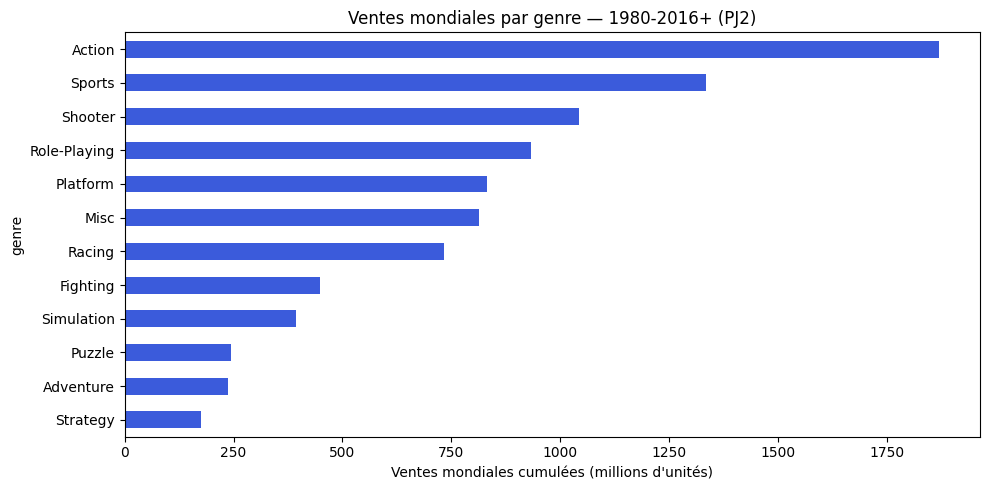

In [9]:
# Ventes mondiales de jeux par genre (PJ2)
genre_sales = df_sales.groupby('genre')['global_sales'].sum().sort_values(ascending=False)

fig, ax = plt.subplots()
genre_sales.plot(kind='barh', ax=ax, color='#3B5BDB')
ax.invert_yaxis()
ax.set_xlabel('Ventes mondiales cumulées (millions d\'unités)')
ax.set_title('Ventes mondiales par genre — 1980-2016+ (PJ2)')
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig_ventes_par_genre.png', dpi=120)
plt.show()


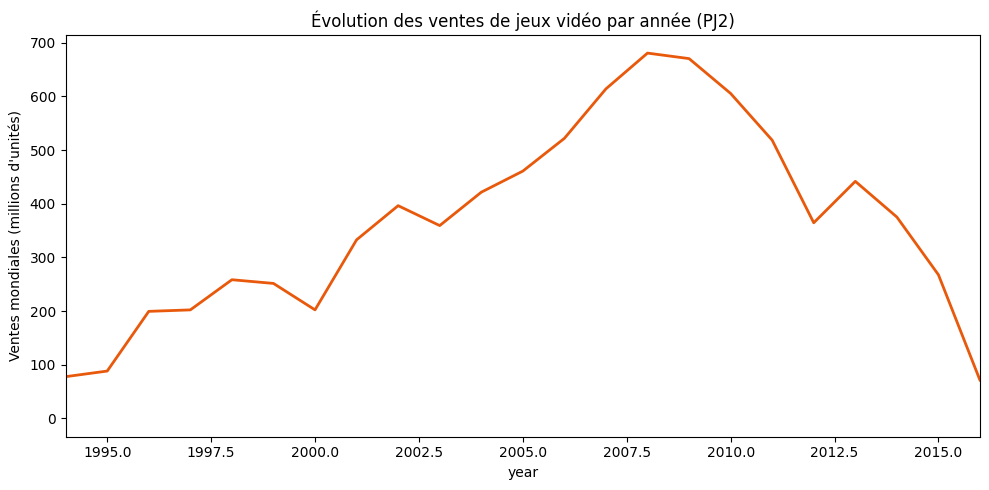


NB : PJ2 est très incomplet après 2012-2013 (la collecte de ce dataset public
s'arrête réellement autour de 2016 malgré quelques lignes jusqu'à 2020).
La baisse apparente après 2013 reflète donc surtout un trou de collecte,
pas un déclin réel du marché -> à ne PAS interpréter tel quel dans le PESTEL,
et à compléter par des sources externes récentes (Phase 2).



In [10]:
# Evolution des ventes globales par année (déclin/essor du marché physique tracké par PJ2)
yearly_sales = df_sales.dropna(subset=['year']).groupby('year')['global_sales'].sum()

fig, ax = plt.subplots()
yearly_sales.plot(ax=ax, color='#E8590C', linewidth=2)
ax.set_ylabel('Ventes mondiales (millions d\'unités)')
ax.set_title('Évolution des ventes de jeux vidéo par année (PJ2)')
ax.set_xlim(1994, 2016)
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig_ventes_par_annee.png', dpi=120)
plt.show()

print('''
NB : PJ2 est très incomplet après 2012-2013 (la collecte de ce dataset public
s'arrête réellement autour de 2016 malgré quelques lignes jusqu'à 2020).
La baisse apparente après 2013 reflète donc surtout un trou de collecte,
pas un déclin réel du marché -> à ne PAS interpréter tel quel dans le PESTEL,
et à compléter par des sources externes récentes (Phase 2).
''')


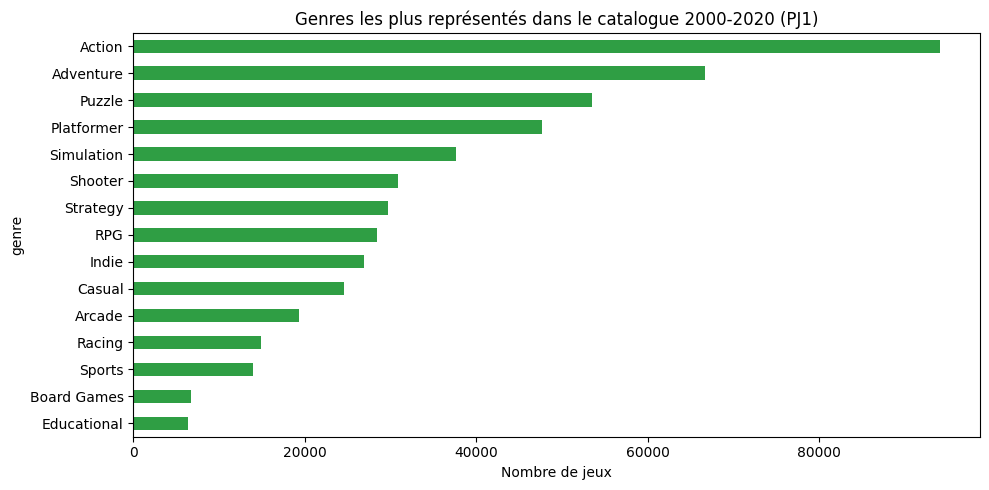

In [11]:
# Répartition des genres dans le catalogue le plus riche et récent (PJ1, 2000-2020)
top_genres_catalog = df_catalog_genres_long['genre'].value_counts().head(15)

fig, ax = plt.subplots()
top_genres_catalog.plot(kind='barh', ax=ax, color='#2F9E44')
ax.invert_yaxis()
ax.set_xlabel('Nombre de jeux')
ax.set_title('Genres les plus représentés dans le catalogue 2000-2020 (PJ1)')
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig_genres_catalogue.png', dpi=120)
plt.show()


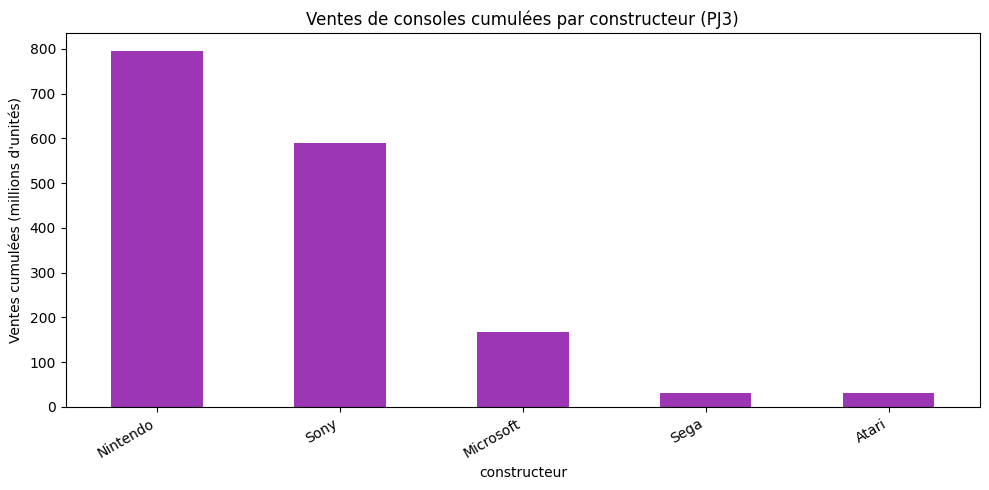

constructeur
Nintendo     795.8742
Sony         590.5010
Microsoft    166.9400
Sega          31.0575
Atari         30.6000
Name: ventes_millions, dtype: float64

In [12]:
# Ventes de consoles par constructeur (PJ3)
console_by_maker = df_console.groupby('constructeur')['ventes_millions'].sum().sort_values(ascending=False)

fig, ax = plt.subplots()
console_by_maker.plot(kind='bar', ax=ax, color='#9C36B5')
ax.set_ylabel('Ventes cumulées (millions d\'unités)')
ax.set_title('Ventes de consoles cumulées par constructeur (PJ3)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(OUT_DIR + 'fig_consoles_par_constructeur.png', dpi=120)
plt.show()

console_by_maker


## 6. Export des données nettoyées

Ces fichiers serviront de base aux phases suivantes (segmentation, corrélations, recommandations) sans avoir à refaire le nettoyage à chaque fois.


In [13]:
# CSV plutôt que parquet : certaines colonnes (ex. slug) mélangent types str/int
# à la lecture .xlsb, ce que pyarrow refuse. CSV n'a pas cette contrainte.
df_catalog.to_csv(OUT_DIR + 'catalog_clean.csv', index=False)
df_catalog_genres_long.to_csv(OUT_DIR + 'catalog_genres_long.csv', index=False)
df_sales.to_csv(OUT_DIR + 'sales_clean.csv', index=False)
df_console.to_csv(OUT_DIR + 'console_clean.csv', index=False)

print('Fichiers exportés dans', OUT_DIR)
import os
for f in os.listdir(OUT_DIR):
    print(' -', f)


Fichiers exportés dans data/
 - catalog_genres_long.csv
 - fig_genres_catalogue.png
 - catalog_clean.csv
 - fig_consoles_par_constructeur.png
 - console_clean.csv
 - fig_ventes_par_genre.png
 - sales_clean.csv
 - fig_ventes_par_annee.png


## 7. Synthèse de la Phase 1

**Ce qui est prêt :**
- 3 bases nettoyées et exportées (`catalog_clean`, `catalog_genres_long`, `sales_clean`, `console_clean`)
- Premiers constats chiffrés : hiérarchie des genres, poids des constructeurs de consoles, limites temporelles des données de ventes

**Points de vigilance à garder en tête pour la suite :**
- PJ2 (ventes) est fiable jusqu'à ~2012-2013 seulement → pour le PESTEL/tendances *actuelles*, il faudra impérativement s'appuyer sur des sources externes récentes (2023-2026), PJ2 ne sert que de socle historique.
- PJ1 n'a pas de données de ventes, seulement des indicateurs d'engagement joueurs (`rating`, `ratings_count`, `playtime`, statuts « possédé/terminé/abandonné ») → très utile pour la segmentation comportementale, pas pour estimer un volume de ventes.
- Aucune donnée démographique (âge, genre du joueur) dans les 3 fichiers → la segmentation démographique devra s'appuyer sur le questionnaire (Phase 4) et des études de marché externes (Phase 2/3).

**Prochaine étape (Phase 2) :** recherche des tendances actuelles/émergentes du marché + construction SWOT et PESTEL.
